# CTR Prediction

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [6]:
train["label"].value_counts(normalize=True)

label
0    0.968
1    0.032
Name: proportion, dtype: float64

40000 rows in train dataset
10000 rows in test dataset

Since there are only 1280 clicks against 38720 no clicks in train dataset, even if a model predicts 0 for everything it will have 96.8% accuracy. Thats why we use other metrics such as Precision, Recall, F1, ROC-AUC

In [7]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    train,
    test_size=0.2,
    random_state=42,
    stratify=train["label"] #makes sure proportionate clicks and no clicks are split in train and validation
)

In [8]:
num_cols = [col for col in train.columns if col.startswith("integer_feature")]
cat_cols = [col for col in train.columns if col.startswith("categorical_feature")]

#splitting numerical feature columns and categorical ones
X_train_num = train_df[num_cols]
X_val_num = val_df[num_cols]

X_train_cat = train_df[cat_cols]
X_val_cat = val_df[cat_cols]

y_train = train_df["label"]
y_val = val_df["label"]

### Numerical Features
As numerical features have a wide range of values, they should be normalised using $$ x' = \frac{x - \mu}{\sigma} $$


In [9]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

#replace NaN values with median of training set so that it is less affected by outliers
num_imputer = SimpleImputer(strategy="median")

X_train_num = num_imputer.fit_transform(X_train_num)
X_val_num = num_imputer.transform(X_val_num)

#now we standardise using the above formula
scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train_num)
X_val_num = scaler.transform(X_val_num) #not fit_transform bcoz val data should not leak into model

### Categorical Features
We create mappings for each category to represent them using integers


In [10]:
X_train_cat = X_train_cat.fillna("UNKNOWN")
X_val_cat = X_val_cat.fillna("UNKNOWN")

cat_maps = {}
cat_cardinalities = {}

for col in cat_cols:
    categories = X_train_cat[col].unique()

    # 0 will represent UNKNOWN
    mapping = {cat: i + 1 for i, cat in enumerate(categories)}

    cat_maps[col] = mapping
    cat_cardinalities[col] = len(mapping) + 1 #reserve one more category for category which might appear in val/test but not present in train

for col in cat_cols:
    X_train_cat[col] = X_train_cat[col].map(cat_maps[col]).fillna(0).astype(int)
    X_val_cat[col] = X_val_cat[col].map(cat_maps[col]).fillna(0).astype(int)

In [11]:
#converting to torch tensors to work in pytorch

X_train_num = torch.tensor(X_train_num, dtype=torch.float32)
X_val_num = torch.tensor(X_val_num, dtype=torch.float32)

X_train_cat = torch.tensor(X_train_cat.values, dtype=torch.long)
X_val_cat = torch.tensor(X_val_cat.values, dtype=torch.long)

In [12]:
y_train = torch.tensor(y_train.values, dtype=torch.float32)
y_val = torch.tensor(y_val.values, dtype=torch.float32)

In [13]:
from torch.utils.data import TensorDataset

train_dataset = TensorDataset(
    X_train_num,
    X_train_cat,
    y_train
)

val_dataset = TensorDataset(
    X_val_num,
    X_val_cat,
    y_val
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

Training samples: 32000
Validation samples: 8000


Now we need to group data into batches and for that we use DataLoader

In [14]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=256,
    shuffle=False #no learning happening during validation
)

For categorical features we cant just use integers to represent categories as that will assume relationships between categories, we avoid one hot encoding as features are higher

Embedding into learnable vectors and finding values by training is better

In [15]:
import torch.nn as nn

embedding_dim = 8 #number of embedding values each category will have
#example mobile = [0.21, -0.42, 0.73, 0.15, 0.32, 0.28, -0.7, 0.98]

embeddings = nn.ModuleList([
    nn.Embedding(cardinality, embedding_dim)
    for cardinality in cat_cardinalities.values()
])

print("Number of embedding layers:", len(embeddings))

Number of embedding layers: 26


Now each batch has 256 rows where each row represents data in combined form of categorical features (26*8)=208 and numerical features(13) 

In [26]:
class CTRModel(nn.Module):
    def __init__(self, num_features, cat_cardinalities, embedding_dim=8):
        super().__init__()

        self.embeddings = nn.ModuleList([
            nn.Embedding(cardinality, embedding_dim)
            for cardinality in cat_cardinalities
        ])

        input_dim = num_features + len(cat_cardinalities) * embedding_dim

        #Multi Layer Perceptron
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
        #we do not add sigmoid as we will use BCEWithLogitLoss() which is sigmoid + BCE Loss

    def forward(self, x_num, x_cat):
        embedded = [
            embedding(x_cat[:, i])
            for i, embedding in enumerate(self.embeddings)
        ]

        x_cat = torch.cat(embedded, dim=1) #concatenate all embeddings of categorical features
        x = torch.cat([x_num, x_cat], dim=1) #concatenate categorical and numerical features

        return self.mlp(x).squeeze(1)


model = CTRModel(
    num_features=len(num_cols),
    cat_cardinalities=list(cat_cardinalities.values()),
    embedding_dim=8
)

print(model)

CTRModel(
  (embeddings): ModuleList(
    (0): Embedding(10858, 8)
    (1): Embedding(3349, 8)
    (2): Embedding(4586, 8)
    (3): Embedding(1614, 8)
    (4): Embedding(3643, 8)
    (5): Embedding(4, 8)
    (6): Embedding(2912, 8)
    (7): Embedding(711, 8)
    (8): Embedding(23, 8)
    (9): Embedding(9625, 8)
    (10): Embedding(4772, 8)
    (11): Embedding(6821, 8)
    (12): Embedding(10, 8)
    (13): Embedding(821, 8)
    (14): Embedding(1833, 8)
    (15): Embedding(43, 8)
    (16): Embedding(5, 8)
    (17): Embedding(310, 8)
    (18): Embedding(15, 8)
    (19): Embedding(11112, 8)
    (20): Embedding(7581, 8)
    (21): Embedding(10423, 8)
    (22): Embedding(4362, 8)
    (23): Embedding(3258, 8)
    (24): Embedding(36, 8)
    (25): Embedding(25, 8)
  )
  (mlp): Sequential(
    (0): Linear(in_features=221, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=Tru

**Loss Function** : Binary Cross Entropy because we have two prediction outputs -> 0 for no click and 1 for click
$$
L = -\frac{1}{N}\sum_{i=1}^{N}
\left[
y_i\log(\hat{y}_i)
+
(1-y_i)\log(1-\hat{y}_i)
\right]
$$
**Optimizer** : We use Adam over SGD because SGD uses gradient descent to convert weights and bias but Adam adapts learning rate for each parameter and hence it is a good pick for neural networks

In [28]:
import torch
import torch.nn as nn

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 10
train_losses = []
val_losses = []

for epoch in range(epochs):
    #Training Loop
    model.train()
    training_loss = 0.0

    for num_batch, cat_batch, label_batch in train_loader:
        #Forward Pass -> Loss -> Backpropagation -> Update weights
        logits = model(num_batch, cat_batch)
        loss = criterion(logits, label_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        training_loss += loss.item()

    training_loss /= len(train_loader)
    train_losses.append(training_loss)

    #Validation Loop
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for num_batch, cat_batch, label_batch in val_loader:
            logits = model(num_batch, cat_batch)
            loss = criterion(logits, label_batch)

            val_loss += loss.item()

        val_loss /= len(val_loader)
        val_losses.append(val_loss)


    print(
        f"Epoch {epoch+1}/{epochs} | ",
        f"Training Loss : {training_loss:.4f} | "
        f"Validation Loss : {val_loss:.4f}"
    )


Epoch 1/10 |  Training Loss : 0.0954 | Validation Loss : 0.1576
Epoch 2/10 |  Training Loss : 0.0800 | Validation Loss : 0.1814
Epoch 3/10 |  Training Loss : 0.0627 | Validation Loss : 0.2023
Epoch 4/10 |  Training Loss : 0.0470 | Validation Loss : 0.2506
Epoch 5/10 |  Training Loss : 0.0361 | Validation Loss : 0.2835
Epoch 6/10 |  Training Loss : 0.0270 | Validation Loss : 0.3200
Epoch 7/10 |  Training Loss : 0.0214 | Validation Loss : 0.3568
Epoch 8/10 |  Training Loss : 0.0169 | Validation Loss : 0.3954
Epoch 9/10 |  Training Loss : 0.0153 | Validation Loss : 0.4173
Epoch 10/10 |  Training Loss : 0.0099 | Validation Loss : 0.4601


The model is overfitting heavily as training loss decreases significantly while validation loss increases

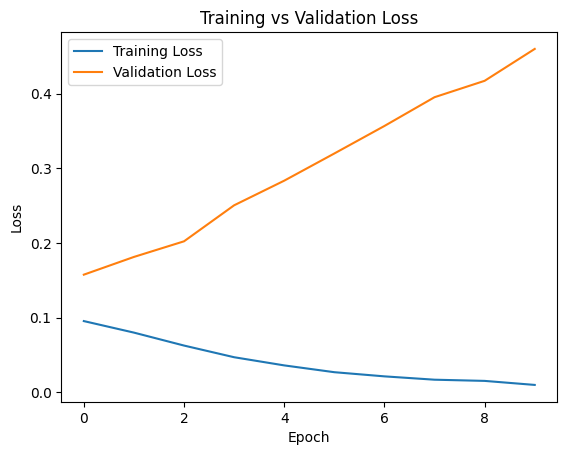

In [29]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.show()

In [30]:
model.eval()

val_probs = []
val_labels = []

with torch.no_grad():
    for num_batch, cat_batch, label_batch in val_loader:

        logits = model(num_batch, cat_batch)

        # Convert logits → probabilities
        probs = torch.sigmoid(logits)

        val_probs.extend(probs.numpy())
        val_labels.extend(label_batch.numpy())

print("Number of predictions:", len(val_probs))
print("First 10 probabilities:", val_probs[:10])
print("First 10 actual labels:", val_labels[:10])

Number of predictions: 8000
First 10 probabilities: [np.float32(7.678061e-06), np.float32(0.0012373339), np.float32(2.3072931e-05), np.float32(3.285487e-10), np.float32(1.5445377e-08), np.float32(5.0414303e-07), np.float32(6.004864e-08), np.float32(0.017754585), np.float32(9.090127e-06), np.float32(3.7422132e-07)]
First 10 actual labels: [np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(1.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0)]


Plotting ROC-AUC Curve and PR-AUC Curve  
These are important bcoz only 3.2% are clicks

In [31]:
from sklearn.metrics import log_loss

val_logloss = log_loss(val_labels, val_probs)

print(f"Validation Log Loss: {val_logloss:.4f}")

Validation Log Loss: 0.4656
